# Rare Disease Genes – Homework 3: Visualization

**Instructions:** Run the Setup cell first, then complete each exercise in order.  
Write your code in the `# YOUR CODE HERE` cells. Answer written questions in the markdown cells below each prompt.

**What you'll learn:**
- Merge two datasets and explore the combined data
- Create bar charts and scatter plots
- Use histograms and box plots to explore distributions
- Build a heatmap to spot patterns across two dimensions
- Investigate disease–gene patterns across chromosomes

---

In [3]:
!pip install pandas matplotlib seaborn numpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 8.7 MB/s  0:00:01 eta 0:00:01m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.2/8.2 MB 9.2 MB/s  0:00:00 eta 0:00:01m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 10.0 MB/s  0:00:00eta 0:00:01m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 8.8 MB/s  0:00:00m eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 8.3 MB/s  0:00:00 eta 0:00:01m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10/10 [seaborn]9/10 [seaborn]ib]

[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: /opt/homebrew/opt/python@3.11/bin/python3.11 -m pip install --upgrade pip


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Load both datasets
diseases = pd.read_csv('https://raw.githubusercontent.com/narayananr/rare_diseases/main/data/rare_gene_disease_dataset.csv')
genes = pd.read_csv('https://raw.githubusercontent.com/narayananr/rare_diseases/main/data/ensembl_genes.csv')

# Calculate gene length
genes['length'] = genes['end'] - genes['start']

print(f'Diseases dataset: {len(diseases)} rows, {diseases.shape[1]} columns')
print(f'Genes dataset: {len(genes)} rows, {genes.shape[1]} columns')
print(f'\nDiseases columns: {list(diseases.columns)}')
print(f'Genes columns: {list(genes.columns)}')

print('\n--- Diseases (first 5 rows) ---')
diseases.head()

Diseases dataset: 8374 rows, 3 columns
Genes dataset: 78691 rows, 9 columns

Diseases columns: ['disease', 'gene_symbol', 'gene_full_name']
Genes columns: ['ensembl_gene_id', 'gene_symbol', 'chromosome', 'start', 'end', 'strand', 'biotype', 'description', 'length']

--- Diseases (first 5 rows) ---


,disease,gene_symbol,gene_full_name
0,Multiple epiphyseal dysplasia-macrocephaly-fac...,KIF7,kinesin family member 7
1,Brachydactyly-short stature-retinitis pigmento...,CWC27,CWC27 spliceosome associated cyclophilin
2,Aspartylglucosaminuria,AGA,aspartylglucosaminidase
3,Multiple sulfatase deficiency,SUMF1,sulfatase modifying factor 1
4,Beta-mannosidosis,MANBA,mannosidase beta


In [5]:
# Look at the genes dataset
print('--- Genes (first 5 rows) ---')
genes.head(5)

--- Genes (first 5 rows) ---


,ensembl_gene_id,gene_symbol,chromosome,start,end,strand,biotype,description,length
0,ENSG00000210049,MT-TF,MT,577,647,1,Mt_tRNA,mitochondrially encoded tRNA-Phe (UUU/C) [Sour...,70
1,ENSG00000211459,MT-RNR1,MT,648,1601,1,Mt_rRNA,mitochondrially encoded 12S rRNA [Source:HGNC ...,953
2,ENSG00000210077,MT-TV,MT,1602,1670,1,Mt_tRNA,mitochondrially encoded tRNA-Val (GUN) [Source...,68
3,ENSG00000210082,MT-RNR2,MT,1671,3229,1,Mt_rRNA,mitochondrially encoded 16S rRNA [Source:HGNC ...,1558
4,ENSG00000209082,MT-TL1,MT,3230,3304,1,Mt_tRNA,mitochondrially encoded tRNA-Leu (UUA/G) 1 [So...,74


### Merging the Datasets

Both datasets share a `gene_symbol` column. By merging, we can connect each disease-gene link to its chromosome location, gene length, and biotype.

**About the `strand` column:** DNA is a double helix with two strands running in opposite directions. Each gene is read from one strand: **forward (1)** or **reverse (-1)**. It's like reading a book — the words are the same, but you can read left-to-right or right-to-left depending on which strand the gene sits on.

In [6]:
# Merge the two datasets on gene_symbol
merged = diseases.merge(genes, on='gene_symbol', how='left')
merged['length'] = merged['end'] - merged['start']

print(f'Merged dataset: {len(merged)} rows, {merged.shape[1]} columns')
print(f'Columns: {list(merged.columns)}')
print('\n--- Merged (first 5 rows) ---')
merged.head()

Merged dataset: 8382 rows, 11 columns
Columns: ['disease', 'gene_symbol', 'gene_full_name', 'ensembl_gene_id', 'chromosome', 'start', 'end', 'strand', 'biotype', 'description', 'length']

--- Merged (first 5 rows) ---


,disease,gene_symbol,gene_full_name,ensembl_gene_id,chromosome,start,end,strand,biotype,description,length
0,Multiple epiphyseal dysplasia-macrocephaly-fac...,KIF7,kinesin family member 7,ENSG00000166813,15,89608789.0,89663098.0,-1.0,protein_coding,kinesin family member 7 [Source:HGNC Symbol;Ac...,54309.0
1,Brachydactyly-short stature-retinitis pigmento...,CWC27,CWC27 spliceosome associated cyclophilin,ENSG00000153015,5,64766368.0,65102412.0,1.0,protein_coding,CWC27 spliceosome associated cyclophilin [Sour...,336044.0
2,Aspartylglucosaminuria,AGA,aspartylglucosaminidase,ENSG00000038002,4,177430774.0,177442444.0,-1.0,protein_coding,aspartylglucosaminidase [Source:HGNC Symbol;Ac...,11670.0
3,Multiple sulfatase deficiency,SUMF1,sulfatase modifying factor 1,ENSG00000144455,3,3700814.0,4467273.0,-1.0,protein_coding,sulfatase modifying factor 1 [Source:HGNC Symb...,766459.0
4,Beta-mannosidosis,MANBA,mannosidase beta,ENSG00000109323,4,102630770.0,102760999.0,-1.0,protein_coding,mannosidase beta [Source:HGNC Symbol;Acc:HGNC:...,130229.0


---
## Part 1: If One Gene Breaks, How Many Diseases Can Result?

Some genes are linked to many different diseases — when they mutate, many things go wrong. These **hub genes** are often involved in fundamental biological processes like cell growth or DNA repair.

**Question: Which genes are connected to the most rare diseases?**

In [7]:
# Step 1: Prepare the data — count diseases per gene
hub_genes = (
    diseases['gene_symbol']
    .value_counts()
    .head(15)
    .reset_index()
)
hub_genes.columns = ['gene_symbol', 'disease_count']

print("Top 15 genes linked to the most diseases:")
hub_genes

Top 15 genes linked to the most diseases:


,gene_symbol,disease_count
0,HBB,29
1,TP53,22
2,LMNA,21
3,KIT,19
4,COL2A1,18
5,FGFR1,17
6,PIK3CA,15
7,HLA-DRB1,14
8,PTEN,14
9,FGFR3,13


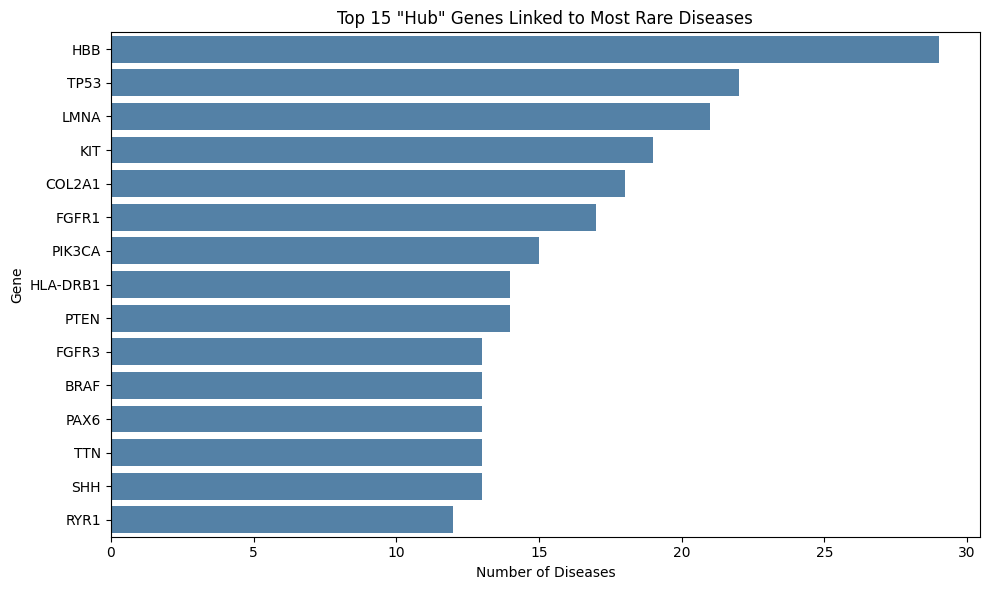

In [8]:
# Step 2: Plot it — horizontal bar chart so gene names are readable
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=hub_genes, x='disease_count', y='gene_symbol', color='steelblue', ax=ax)
ax.set_xlabel('Number of Diseases')
ax.set_ylabel('Gene')
ax.set_title('Top 15 \"Hub\" Genes Linked to Most Rare Diseases')
plt.tight_layout()
plt.show()

**Think about it** (double-click to edit):

1. Look up the #1 gene online. What does it do? Why might it be linked to so many diseases?  
   *Your answer:*

---
## Part 2: Are Some Diseases Genetically Simple While Others Are Complex?

Some diseases are caused by a single gene mutation — one gene breaks, one disease results. Others are genetically complex — dozens of different genes can cause or contribute to them.

**Question: Which rare diseases involve the most genes?**

In [9]:
# Step 1: Prepare the data — count genes per disease
complex_diseases = (
    diseases['disease']
    .value_counts()
    .head(15)
    .reset_index()
)
complex_diseases.columns = ['disease', 'gene_count']

print("Top 15 most genetically complex diseases:")
complex_diseases

Top 15 most genetically complex diseases:


,disease,gene_count
0,Non-specific syndromic intellectual disability,114
1,Retinitis pigmentosa,88
2,Rare autosomal recessive non-syndromic sensori...,74
3,Non-specific early-onset epileptic encephalopathy,54
4,Autosomal recessive non-syndromic intellectual...,54
5,Familial isolated dilated cardiomyopathy,53
6,Primary ciliary dyskinesia,53
7,Rare autosomal dominant non-syndromic sensorin...,50
8,Autosomal dominant non-syndromic intellectual ...,43
9,Male infertility with azoospermia or oligozoos...,37


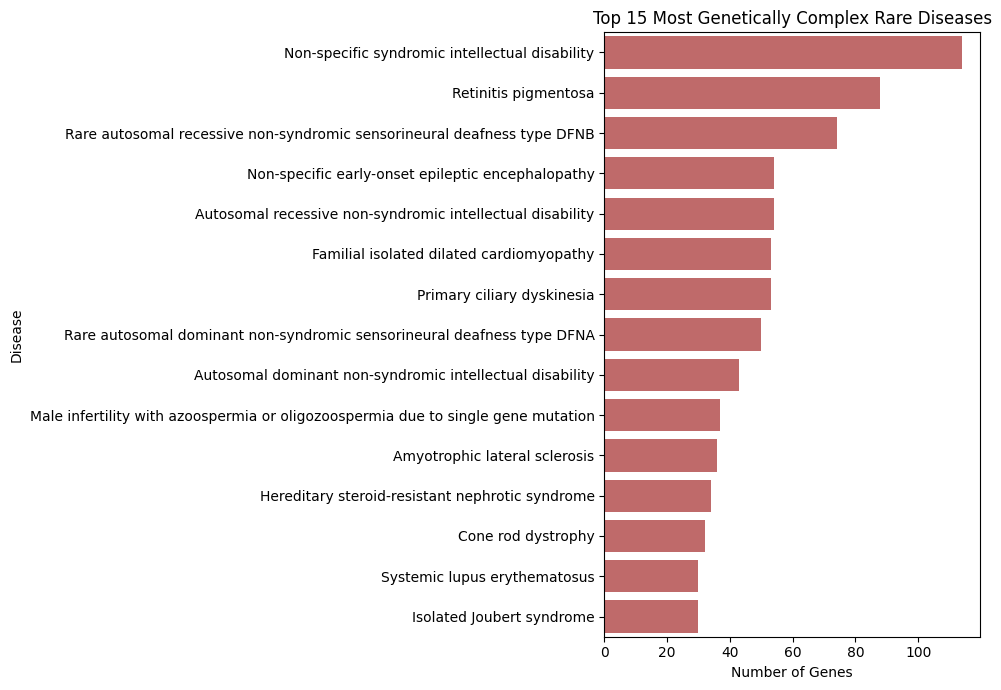

In [10]:
# Step 2: Plot it
fig, ax = plt.subplots(figsize=(10, 7))
sns.barplot(data=complex_diseases, x='gene_count', y='disease', color='indianred', ax=ax)
ax.set_xlabel('Number of Genes')
ax.set_ylabel('Disease')
ax.set_title('Top 15 Most Genetically Complex Rare Diseases')
plt.tight_layout()
plt.show()

**Think about it** (double-click to edit):

1. What is the most genetically complex disease? How many genes are involved?  
   *Your answer:*

2. Why might some diseases involve many genes while others involve only one?  
   *Your answer:*

### 🎯 Exercise: What About the Simplest Diseases?

We used `.head(15)` to get the most complex diseases. **What if we use `.tail(15)` to get the simplest?**

Create a `simple_diseases` DataFrame using `.value_counts().tail(15)` and plot it.

In [11]:
# YOUR CODE HERE — Step 1: Create simple_diseases DataFrame

# Step 1: Prepare the data — count genes per disease
simple_diseases = (
    diseases['disease']
    .value_counts()
    .tail(15)
    .reset_index()
)
simple_diseases.columns = ['disease', 'gene_count']

print("Top 15 most genetically simple diseases:")
simple_diseases

Top 15 most genetically simple diseases:


,disease,gene_count
0,Primary hypomagnesemia-generalized seizures-in...,1
1,Bartter syndrome type 2,1
2,Non-syndromic non-specific multisutural cranio...,1
3,MIR140-related spondyloepiphyseal dysplasia,1
4,X-linked severe syndromic thoracic aortic aneu...,1
5,SBDS-related severe neonatal spondylometaphyse...,1
6,F12-associated cold autoinflammatory syndrome,1
7,Congenital neutropenia-combined immunodeficien...,1
8,SAMD9L-associated autoinflammatory syndrome,1
9,Familial hyperinflammatory lymphoproliferative...,1


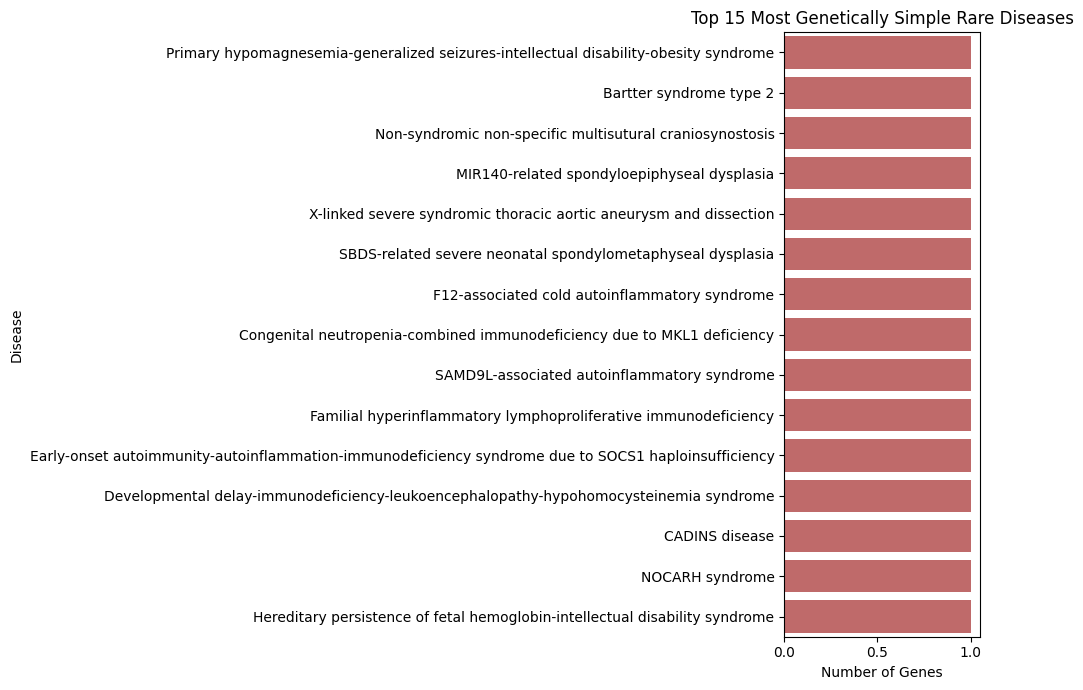

In [12]:
# YOUR CODE HERE — Step 2: Plot it using sns.barplot()

fig, ax = plt.subplots(figsize=(10, 7))
sns.barplot(data=simple_diseases, x='gene_count', y='disease', color='indianred', ax=ax)
ax.set_xlabel('Number of Genes')
ax.set_ylabel('Disease')
ax.set_title('Top 15 Most Genetically Simple Rare Diseases')
plt.tight_layout()
plt.show()


<details>
<summary>💡 Click here for the solution</summary>

```python
# Step 1: Create simple_diseases DataFrame
simple_diseases = (
    diseases['disease']
    .value_counts()
    .tail(15)
    .reset_index()
)
simple_diseases.columns = ['disease', 'gene_count']
simple_diseases

# Step 2: Plot it
fig, ax = plt.subplots(figsize=(10, 7))
sns.barplot(data=simple_diseases, x='gene_count', y='disease', color='mediumseagreen', ax=ax)
ax.set_xlabel('Number of Genes')
ax.set_ylabel('Disease')
ax.set_title('15 Simplest Rare Diseases (Fewest Genes)')
plt.tight_layout()
plt.show()
```

</details>

**Answer these questions** (double-click to edit):

1. How many genes are the simplest diseases linked to?  
   *Your answer:*
   Only 1

2. Compare this chart to the complex diseases chart above. What's the range — from simplest to most complex?  
   *Your answer:*
   Complex diseases range from 30 to 114 genes per disease, showing us how many factors cause it, while every single one of the simple diseases were only linked to one gene. 

---
## Part 3: Can We Count Two Things at Once?

So far we've counted one column at a time. A **heatmap** uses color to show counts across *two* columns in a grid — rows are one category, columns are another.

**Question: Are certain gene types concentrated on specific chromosomes?**

`pd.crosstab()` counts how often each combination of two columns occurs — one line creates the entire grid.

In [13]:
# Step 1: Prepare the data — one line with pd.crosstab
unique_disease_genes = merged.drop_duplicates(subset='gene_symbol').dropna(subset=['biotype', 'chromosome'])

# crosstab counts how many genes have each biotype × chromosome combination
biotype_chrom = pd.crosstab(unique_disease_genes['biotype'], unique_disease_genes['chromosome'])

# Keep only the top 5 biotypes (rows) and standard chromosomes (columns)
chrom_order = [str(i) for i in range(1, 23)] + ['X', 'Y']
top_biotypes = unique_disease_genes['biotype'].value_counts().head(5).index
biotype_chrom = biotype_chrom.loc[top_biotypes, chrom_order]

print("Gene count by biotype x chromosome:")
biotype_chrom

Gene count by biotype x chromosome:


chromosome,1,2,3,4,5,6,7,8,9,10,...,15,16,17,18,19,20,21,22,X,Y
biotype,,,,,,,,,,,,,,,,,,,,,
protein_coding,429,317,282,177,204,227,205,147,166,178,...,146,198,262,64,224,106,45,106,238,12
Mt_tRNA,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
lncRNA,0,1,2,0,1,1,0,0,0,1,...,0,1,0,0,0,0,0,0,0,0
IG_C_gene,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
snRNA,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0


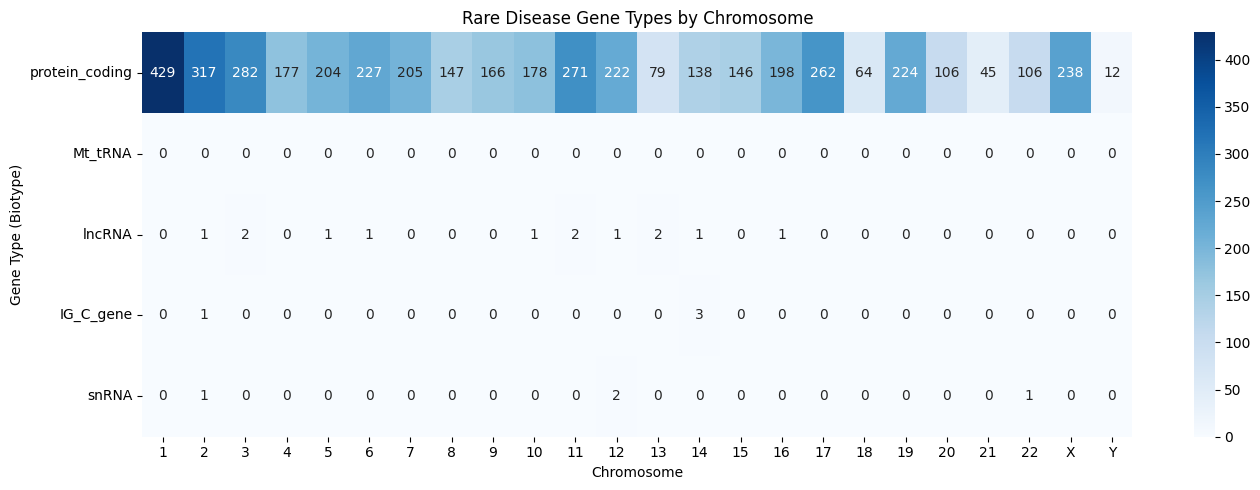

In [14]:
# Step 2: Plot it
fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(biotype_chrom, annot=True, fmt='d', cmap='Blues', ax=ax)
ax.set_xlabel('Chromosome')
ax.set_ylabel('Gene Type (Biotype)')
ax.set_title('Rare Disease Gene Types by Chromosome')
plt.tight_layout()
plt.show()

### Another Simple Heatmap: Strand × Chromosome

Genes can sit on the **forward strand (1)** or **reverse strand (-1)** of DNA. Are disease genes evenly split between the two strands on each chromosome, or is there a bias?

**Question: Do some chromosomes have more disease genes on one strand than the other?**

In [15]:
# Step 1: Prepare the data — one line with pd.crosstab
chrom_order = [str(i) for i in range(1, 23)] + ['X', 'Y']

# Label strands so the heatmap is readable
unique_disease_genes = merged.drop_duplicates(subset='gene_symbol').dropna(subset=['strand', 'chromosome']).copy()
unique_disease_genes['strand_label'] = unique_disease_genes['strand'].map({1: 'Forward (+)', -1: 'Reverse (-)'})

strand_chrom = pd.crosstab(unique_disease_genes['strand_label'], unique_disease_genes['chromosome'])
strand_chrom = strand_chrom[chrom_order]

print("Disease genes by strand x chromosome:")
strand_chrom

Disease genes by strand x chromosome:


chromosome,1,2,3,4,5,6,7,8,9,10,...,15,16,17,18,19,20,21,22,X,Y
strand_label,,,,,,,,,,,,,,,,,,,,,
Forward (+),225,148,137,103,101,105,93,63,81,93,...,64,113,125,30,111,55,17,56,128,9
Reverse (-),204,172,147,75,104,123,113,85,87,86,...,83,87,138,34,113,51,28,51,110,3


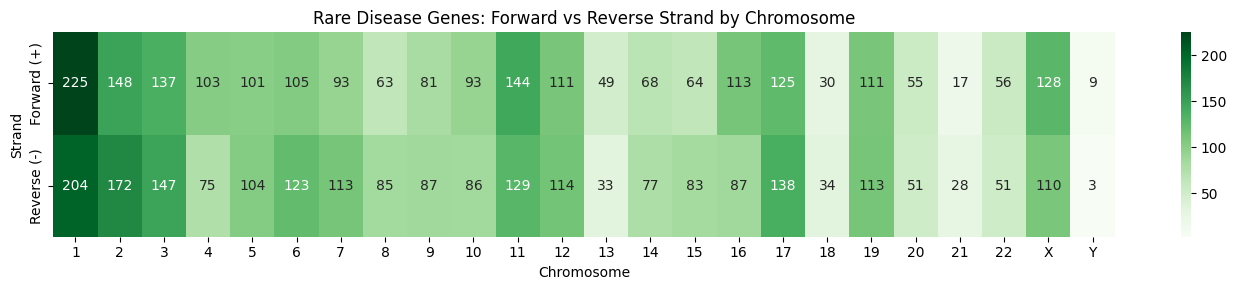

In [16]:
# Step 2: Plot it
fig, ax = plt.subplots(figsize=(14, 3))
sns.heatmap(strand_chrom, annot=True, fmt='d', cmap='Greens', ax=ax)
ax.set_xlabel('Chromosome')
ax.set_ylabel('Strand')
ax.set_title('Rare Disease Genes: Forward vs Reverse Strand by Chromosome')
plt.tight_layout()
plt.show()

### Heatmap Quick Reference

| Line | What it does |
|------|--------------|
| `pd.crosstab(df['col1'], df['col2'])` | Count combinations of two columns (simplest way to build a heatmap grid) |
| `sns.heatmap(df)` | Create a heatmap from a DataFrame |
| `annot=True` | Show numbers in each cell |
| `fmt='d'` or `fmt='.0f'` | Format numbers as integers |
| `cmap='YlOrRd'` | Color scheme. Try `'Blues'`, `'Greens'`, `'viridis'` |

---
## Part 4: Do Different Gene Types Have Different Sizes?

Not all genes are the same type. Protein-coding genes make proteins; lncRNAs regulate other genes; pseudogenes are broken copies. These different **biotypes** might have very different size characteristics.

**Question: How does gene length vary across different types of rare disease genes?**

In [17]:
# Step 1: Prepare the data
unique_disease_genes = merged.drop_duplicates(subset='gene_symbol').copy()
top5_biotypes = unique_disease_genes['biotype'].value_counts().head(5)

print("Top 5 biotypes of rare disease genes:")
print(top5_biotypes)

plot_data = unique_disease_genes[unique_disease_genes['biotype'].isin(top5_biotypes.index)]
print(f"\nFiltered to {len(plot_data)} genes for plotting")

Top 5 biotypes of rare disease genes:
biotype
protein_coding    4456
Mt_tRNA             15
lncRNA              13
IG_C_gene            4
snRNA                4
Name: count, dtype: int64

Filtered to 4492 genes for plotting


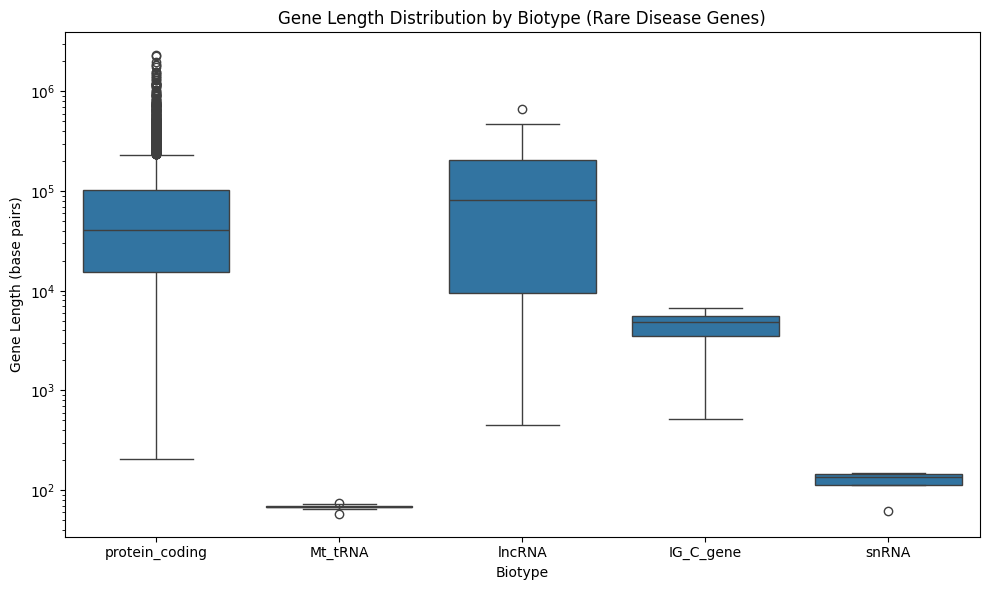

In [18]:
# Step 2: Plot it
fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(data=plot_data, x='biotype', y='length', order=top5_biotypes.index, ax=ax)
ax.set_ylabel('Gene Length (base pairs)')
ax.set_xlabel('Biotype')
ax.set_title('Gene Length Distribution by Biotype (Rare Disease Genes)')

# Log scale: each step on the y-axis is 10× the previous one
# Useful when values range from thousands to millions
ax.set_yscale('log')
plt.tight_layout()
plt.show()

### Seeing the Actual Data Points

Box plots summarize the distribution, but hide the individual genes. Adding **jittered data points** on top shows every gene as a dot — you can see how many genes are in each group and where they cluster.

`sns.stripplot()` adds one dot per gene, with random horizontal jitter so dots don't overlap.

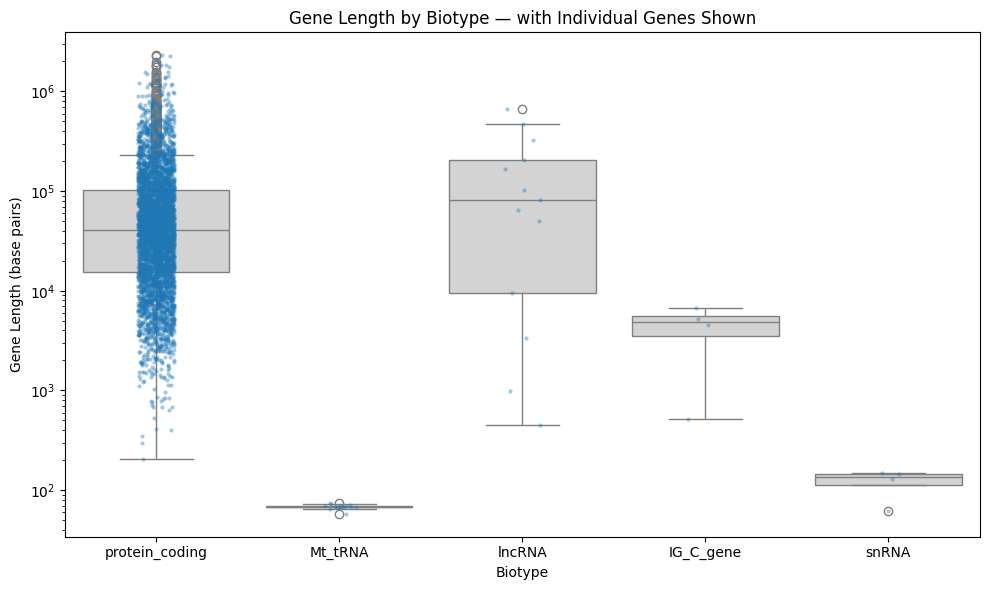

In [19]:
# Same box plot, but with jittered data points on top
fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(data=plot_data, x='biotype', y='length', order=top5_biotypes.index, ax=ax, color='lightgray')
sns.stripplot(data=plot_data, x='biotype', y='length', order=top5_biotypes.index,
              size=3, alpha=0.4, jitter=True, ax=ax)
ax.set_ylabel('Gene Length (base pairs)')
ax.set_xlabel('Biotype')
ax.set_title('Gene Length by Biotype — with Individual Genes Shown')
ax.set_yscale('log')
plt.tight_layout()
plt.show()

### Do Different Disease Types Have Different Gene Sizes?

We compared gene types (biotypes) above. Now let's compare **disease types** — are cancer genes, heart genes, and brain genes different sizes?

**Question: Does gene length vary across disease categories?**

In [20]:
# Step 1: Prepare the data — filter merged for each disease keyword, label, and combine
keywords = ['cancer', 'cardiac', 'eye', 'kidney', 'muscle']

frames = []
for kw in keywords:
    filtered = merged[merged['disease'].str.contains(kw, case=False)]
    filtered_genes = filtered.drop_duplicates(subset='gene_symbol')[['gene_symbol', 'length']].copy()
    filtered_genes['category'] = kw
    frames.append(filtered_genes)

# pd.concat stacks them into one DataFrame
category_lengths = pd.concat(frames, ignore_index=True).dropna(subset=['length'])

print(f"Genes per category:")
print(category_lengths['category'].value_counts())

Genes per category:
category
cancer     44
muscle     34
kidney     31
cardiac    23
eye        19
Name: count, dtype: int64


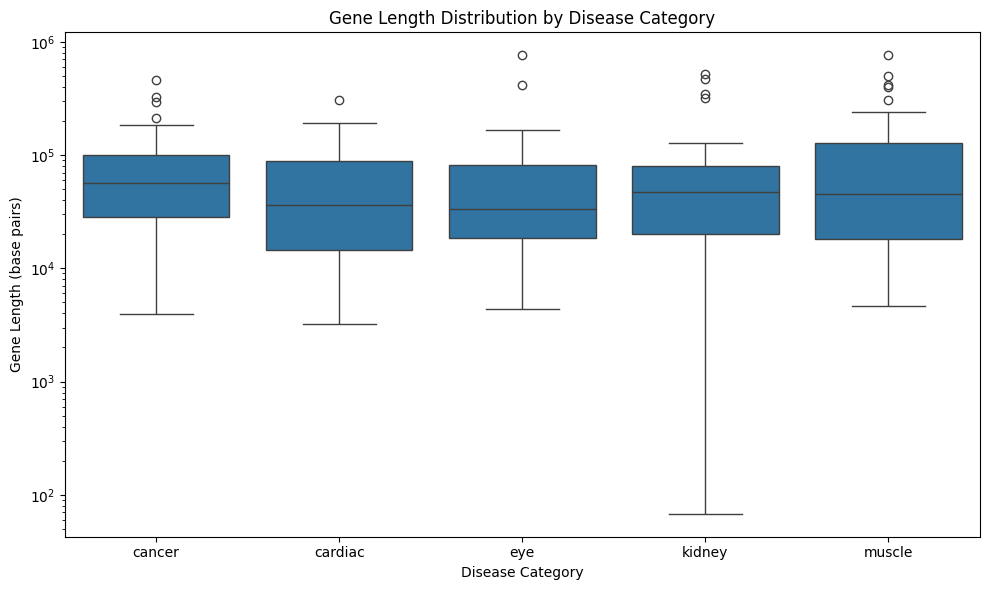

In [21]:
# Step 2: Plot it
fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(data=category_lengths, x='category', y='length', order=keywords, ax=ax)
ax.set_xlabel('Disease Category')
ax.set_ylabel('Gene Length (base pairs)')
ax.set_title('Gene Length Distribution by Disease Category')
ax.set_yscale('log')
plt.tight_layout()
plt.show()

**Think about it** (double-click to edit):

1. Which disease category has the longest genes? Which has the shortest?  
   *Your answer:* Muscle

2. Why might muscle disease genes be a different size than eye disease genes?  
   *Your answer:* Due to the size difference between the size of the eye and the sizes of muscles, showing us that the genes need to be small enough to fit each respectively, and hence genes in the eye would be shorter

### Box Plot Quick Reference

| Line | What it does |
|------|--------------|
| `sns.boxplot(data=df, x='col1', y='col2')` | Create a box plot grouped by `x` |
| `order=[...]` | Control the order of categories on x-axis |
| `ax.set_yscale('log')` | Use log scale (helpful when values span many orders of magnitude) |

### 🎯 Exercise 1: How Variable Are Gene Sizes Across Chromosomes?

Some chromosomes might have consistently sized disease genes, while others might have a wide range from tiny to enormous.

**Question: Which chromosomes have the most variable rare disease gene sizes?**

Create a box plot to find out.

*Hints:*
- Use `unique_disease_genes` (already created above)
- Set `x='chromosome'` and `y='length'`
- Use `order=chrom_order` to sort chromosomes logically
- Use `ax.set_yscale('log')` since gene lengths vary a lot
- Make the figure wide: `figsize=(14, 6)`

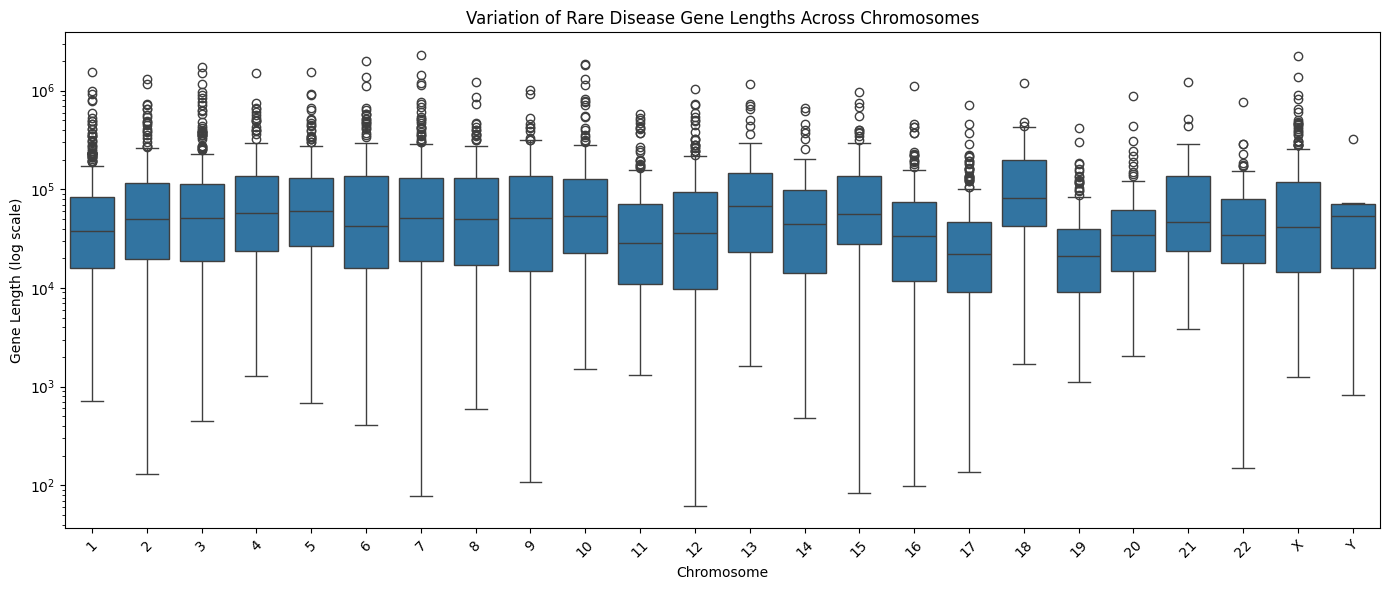

In [22]:
# YOUR CODE HERE: Box plot of gene length by chromosome

plt.figure(figsize=(14, 6))

ax = sns.boxplot(
    data=unique_disease_genes,
    x="chromosome",
    y="length",
    order=chrom_order
)

# Log scale because gene lengths vary massively
ax.set_yscale("log")

ax.set_title("Variation of Rare Disease Gene Lengths Across Chromosomes")
ax.set_xlabel("Chromosome")
ax.set_ylabel("Gene Length (log scale)")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


<details>
<summary>💡 Click here for the solution</summary>

```python
chrom_order = [str(i) for i in range(1, 23)] + ['X', 'Y']

fig, ax = plt.subplots(figsize=(14, 6))
sns.boxplot(data=unique_disease_genes, x='chromosome', y='length',
            order=chrom_order, ax=ax)
ax.set_ylabel('Gene Length (base pairs)')
ax.set_xlabel('Chromosome')
ax.set_title('Gene Length Distribution by Chromosome (Rare Disease Genes)')
ax.set_yscale('log')
plt.tight_layout()
plt.show()
```

</details>

**Answer these questions** (double-click to edit):

1. Which chromosome has the widest spread of gene lengths? Which has the narrowest?  
   *Your answer:* Chromosomes like Chromosome 1 (and often Chromosome X) show the widest spread of gene lengths, indicating high variability. Smaller chromosomes (such as Chromosome 21 or Chromosome 22) tend to have a narrower spread, meaning gene lengths are more consistent.

2. Are there many outliers (dots)? What does an outlier mean in this context?  
   *Your answer:* Yes, there are many outliers visible as dots above or below the boxes. In this context, an outlier represents a gene whose length is unusually large or small compared to most genes on that chromosome. These could be extremely long genes or very short ones that fall far outside the typical range.

---
## Part 5: Where Do Disease Genes Live?

Humans have 23 pairs of chromosomes, but are rare disease genes spread evenly across them — or do some chromosomes carry more than their fair share?

**Question: Which chromosomes carry the most rare disease genes?**

In [23]:
# Step 1: Prepare the data
chrom_order = [str(i) for i in range(1, 23)] + ['X', 'Y', 'MT']

disease_by_chrom = (
    merged['chromosome']
    .value_counts()
    .reindex(chrom_order)
    .dropna()
    .reset_index()
)
disease_by_chrom.columns = ['chromosome', 'count']

print("Disease-gene links per chromosome:")
disease_by_chrom

Disease-gene links per chromosome:


,chromosome,count
0,1,773
1,2,615
2,3,523
3,4,322
4,5,353
5,6,402
6,7,360
7,8,275
8,9,312
9,10,339


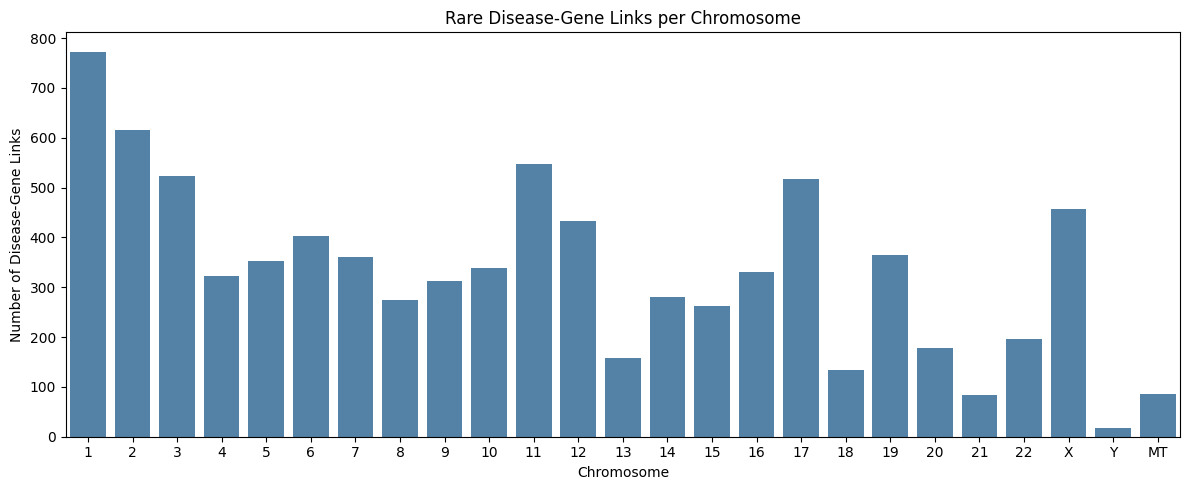

In [24]:
# Step 2: Plot it
fig, ax = plt.subplots(figsize=(12, 5))
sns.barplot(data=disease_by_chrom, x='chromosome', y='count', color='steelblue', ax=ax)
ax.set_xlabel('Chromosome')
ax.set_ylabel('Number of Disease-Gene Links')
ax.set_title('Rare Disease-Gene Links per Chromosome')
plt.tight_layout()
plt.show()

### 🎯 Exercise 2: Does Counting Method Matter?

The chart above counts disease-gene **links** — but one gene can appear many times if it’s linked to many diseases. **Does the picture change when we count unique genes instead?**

Create a chart that counts **unique genes** per chromosome.

*Hints:*
- Use `merged.drop_duplicates(subset='gene_symbol')` to get one row per gene
- Then count by chromosome with `.value_counts()` and `.reindex(chrom_order)`
- Use the demo chart above as a template

In [ ]:
# YOUR CODE HERE: Bar chart of unique rare disease genes per chromosome
# Step 1: Keep only one row per gene
unique_genes = merged.drop_duplicates(subset="gene_symbol")

# Step 2: Count genes per chromosome
gene_counts = (
    unique_genes["chromosome"]
    .value_counts()
    .reindex(chrom_order)
)
# Step 3: Plot it
plt.figure(figsize=(14, 6))

sns.barplot(
    x=gene_counts.index,
    y=gene_counts.values
)

plt.title("Number of Unique Rare Disease Genes per Chromosome")
plt.xlabel("Chromosome")
plt.ylabel("Number of Unique Genes")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


<details>
<summary>💡 Click here for the solution</summary>

```python
# Step 1: Prepare the data
chrom_order = [str(i) for i in range(1, 23)] + ['X', 'Y', 'MT']
unique_genes = merged.drop_duplicates(subset='gene_symbol')
unique_by_chrom = (
    unique_genes['chromosome']
    .value_counts()
    .reindex(chrom_order)
    .dropna()
    .reset_index()
)
unique_by_chrom.columns = ['chromosome', 'count']
unique_by_chrom

# Step 2: Plot it
fig, ax = plt.subplots(figsize=(12, 5))
sns.barplot(data=unique_by_chrom, x='chromosome', y='count', color='steelblue', ax=ax)
ax.set_xlabel('Chromosome')
ax.set_ylabel('Number of Unique Rare Disease Genes')
ax.set_title('Unique Rare Disease Genes per Chromosome')
plt.tight_layout()
plt.show()
```

</details>

**Answer these questions** (double-click to edit):

1. Which chromosome has the most unique rare disease genes?  
   *Your answer:*

2. Does chromosome size seem to matter? (Chromosome 1 is the largest, chromosome 21 is one of the smallest.)  
   *Your answer:*

3. How does the X chromosome compare to similarly-sized autosomes?  
   *Your answer:*

### Is Chromosome 1 Really Special, or Just Big?

The bar chart shows chromosome 1 has the most disease genes — but it’s also the **largest** chromosome with the most genes overall.

**Question: Which chromosomes have a disproportionately high fraction of disease genes?**

To answer this, we calculate **enrichment** — what percentage of each chromosome’s genes are linked to rare diseases. This normalizes for chromosome size.

In [ ]:
# Step 1: Prepare the data — calculate % of genes that are disease-related
chrom_order = [str(i) for i in range(1, 23)] + ['X', 'Y']

total_per_chrom = genes[genes['chromosome'].isin(chrom_order)].groupby('chromosome').size()

unique_disease = merged.drop_duplicates(subset='gene_symbol')
rare_per_chrom = (
    unique_disease[unique_disease['chromosome'].isin(chrom_order)]
    .groupby('chromosome').size()
)

enrichment_df = pd.DataFrame({
    'chromosome': chrom_order,
    'total_genes': total_per_chrom.reindex(chrom_order).values,
    'rare_disease_genes': rare_per_chrom.reindex(chrom_order).fillna(0).astype(int).values
})
enrichment_df['pct_disease'] = (enrichment_df['rare_disease_genes'] / enrichment_df['total_genes'] * 100).round(1)

print("Disease gene enrichment (% of genes that are disease-related):")
enrichment_df

In [ ]:
# Step 2: Plot it
fig, ax = plt.subplots(figsize=(12, 5))
sns.barplot(data=enrichment_df, x='chromosome', y='pct_disease', color='coral', ax=ax)
ax.set_xlabel('Chromosome')
ax.set_ylabel('% of Genes Linked to Rare Diseases')
ax.set_title('Disease Gene Enrichment by Chromosome')
ax.axhline(y=enrichment_df['pct_disease'].mean(), color='gray', linestyle='--', label='Average')
ax.legend()
plt.tight_layout()
plt.show()

print(f"Average across chromosomes: {enrichment_df['pct_disease'].mean():.1f}%")

**Compare the two charts** (double-click to edit):

1. Which chromosome ranks highest in raw count? Which ranks highest in enrichment (%)? Are they the same?  
   *Your answer:*

2. Why is enrichment a more meaningful measure than raw count?  
   *Your answer:*

---
## Part 6: Do Disease Types Cluster on Specific Chromosomes?

Cancer genes, heart disease genes, and brain disease genes might not be spread randomly across the genome. Some chromosomes might be hotspots for certain disease types.

**Question: Are cancer-related genes concentrated on particular chromosomes?**

In [ ]:
# Step 1: Prepare the data
keyword = 'cancer'
chrom_order = [str(i) for i in range(1, 23)] + ['X', 'Y']

category = merged[merged['disease'].str.contains(keyword, case=False)]
category_genes = category.drop_duplicates(subset='gene_symbol')
chrom_counts = (
    category_genes['chromosome']
    .value_counts()
    .reindex(chrom_order)
    .dropna()
    .reset_index()
)
chrom_counts.columns = ['chromosome', 'count']

print(f"Unique '{keyword}' disease genes: {len(category_genes)}")
print(f"\nGenes per chromosome:")
chrom_counts

In [ ]:
# Step 2: Plot it
fig, ax = plt.subplots(figsize=(12, 5))
sns.barplot(data=chrom_counts, x='chromosome', y='count', color='indianred', ax=ax)
ax.set_xlabel('Chromosome')
ax.set_ylabel(f'Unique Genes linked to "{keyword}" diseases')
ax.set_title(f'Rare Disease Genes for "{keyword}" by Chromosome')
plt.tight_layout()
plt.show()

### 🎯 Exercise 3: Does the Pattern Hold for Other Disease Types?

Cancer genes cluster on certain chromosomes. **Is the pattern different for other disease categories — like heart, eye, or kidney diseases?**

Pick a different keyword and find out.

| Body system | Keywords | Condition types | Keywords |
|-------------|----------|-----------------|----------|
| Kidney | `kidney`, `renal` | Cancer | `cancer`, `tumor` |
| Liver | `liver`, `hepatic` | Muscle | `dystrophy`, `myopathy` |
| Eye | `eye`, `retinal` | Brain | `epilepsy`, `ataxia` |
| Heart | `heart`, `cardiac` | Blood | `anemia`, `thrombosis` |
| Lung | `lung`, `pulmonary` | Hearing | `deafness`, `hearing` |

In [ ]:
# YOUR CODE HERE: Pick a keyword and create a chromosome bar chart
my_keyword = ''   # Fill in your keyword

if not my_keyword:
    raise ValueError("Please fill in your keyword before running this cell!")

# Step 1: Prepare the data
chrom_order = [str(i) for i in range(1, 23)] + ['X', 'Y']
category = merged[merged['disease'].str.contains(my_keyword, case=False)]
category_genes = category.drop_duplicates(subset='gene_symbol')
chrom_counts = (
    category_genes['chromosome']
    .value_counts()
    .reindex(chrom_order)
    .dropna()
    .reset_index()
)
chrom_counts.columns = ['chromosome', 'count']
print(f"Unique '{my_keyword}' disease genes: {len(category_genes)}")
chrom_counts

# Step 2: Plot it
# YOUR CODE HERE: use sns.barplot() — copy the pattern from the demo above



<details>
<summary>💡 Click here for the solution</summary>

```python
# Step 1: Prepare the data
my_keyword = 'cardiac'
chrom_order = [str(i) for i in range(1, 23)] + ['X', 'Y']

category = merged[merged['disease'].str.contains(my_keyword, case=False)]
category_genes = category.drop_duplicates(subset='gene_symbol')
chrom_counts = (
    category_genes['chromosome']
    .value_counts()
    .reindex(chrom_order)
    .dropna()
    .reset_index()
)
chrom_counts.columns = ['chromosome', 'count']
chrom_counts

# Step 2: Plot it
fig, ax = plt.subplots(figsize=(12, 5))
sns.barplot(data=chrom_counts, x='chromosome', y='count', color='indianred', ax=ax)
ax.set_xlabel('Chromosome')
ax.set_ylabel(f'Unique Genes linked to "{my_keyword}" diseases')
ax.set_title(f'Rare Disease Genes for "{my_keyword}" by Chromosome')
plt.tight_layout()
plt.show()
```

</details>

**Answer these questions** (double-click to edit):

1. Which keyword did you choose?  
   *Your answer:*

2. Which chromosome has the most genes for your category?  
   *Your answer:*

3. Are the results different from the cancer example? What might explain the differences?  
   *Your answer:*

---
## Part 7: Are Disease Genes Bigger Than Normal?

Genes vary hugely in size — some are a few hundred base pairs, others span millions. Larger genes make bigger targets for mutations.

**Question: Are rare disease genes longer or shorter than the average human gene?**

In [ ]:
# Gene length is already calculated in the setup cell
unique_disease_genes = merged.drop_duplicates(subset='gene_symbol').copy()

# Compare averages
avg_all = genes['length'].mean()
avg_rare = unique_disease_genes['length'].dropna().mean()

print(f"Average gene length (all genes):          {avg_all:,.0f} base pairs")
print(f"Average gene length (rare disease genes):  {avg_rare:,.0f} base pairs")

### Does Gene Size Vary by Chromosome?

We know the overall average — but do some chromosomes have longer disease genes than others?

**Question: Which chromosomes carry the longest rare disease genes?**

In [ ]:
# Step 1: Prepare the data
chrom_order = [str(i) for i in range(1, 23)] + ['X', 'Y']

rare_length_by_chrom = (
    unique_disease_genes
    .groupby('chromosome')['length']
    .mean()
    .reindex(chrom_order)
    .reset_index()
)
rare_length_by_chrom.columns = ['chromosome', 'avg_length']
rare_length_by_chrom['avg_length_kb'] = rare_length_by_chrom['avg_length'] / 1000

print("Average rare disease gene length per chromosome (kb):")
rare_length_by_chrom[['chromosome', 'avg_length_kb']]

In [ ]:
# Step 2: Plot it
fig, ax = plt.subplots(figsize=(14, 5))
sns.barplot(data=rare_length_by_chrom, x='chromosome', y='avg_length_kb', color='steelblue', ax=ax)
ax.set_xlabel('Chromosome')
ax.set_ylabel('Average Gene Length (kb)')
ax.set_title('Average Rare Disease Gene Length by Chromosome')
plt.tight_layout()
plt.show()

---
## Part 8: Do More Genes Mean More Disease?

Some chromosomes have thousands of genes, others have hundreds. If disease genes were randomly distributed, chromosomes with more genes should have proportionally more disease genes.

**Question: Is the number of disease genes on a chromosome simply proportional to its total gene count — or are some chromosomes outliers?**

In [ ]:
# Step 1: Prepare the data — build a table with both counts per chromosome
chrom_order = [str(i) for i in range(1, 23)] + ['X', 'Y']

total_per_chrom = genes[genes['chromosome'].isin(chrom_order)].groupby('chromosome').size()

unique_disease = merged.drop_duplicates(subset='gene_symbol')
rare_per_chrom = (
    unique_disease[unique_disease['chromosome'].isin(chrom_order)]
    .groupby('chromosome').size()
)

chrom_df = pd.DataFrame({
    'chromosome': chrom_order,
    'total_genes': total_per_chrom.reindex(chrom_order).values,
    'rare_disease_genes': rare_per_chrom.reindex(chrom_order).fillna(0).astype(int).values
})

print("Genes per chromosome:")
chrom_df

In [ ]:
# Step 2: Plot it
fig, ax = plt.subplots(figsize=(8, 6))
sns.scatterplot(data=chrom_df, x='total_genes', y='rare_disease_genes', s=80, color='steelblue', ax=ax)

# Label each dot with the chromosome name
for _, row in chrom_df.iterrows():
    ax.annotate(row['chromosome'], (row['total_genes'], row['rare_disease_genes']),
                textcoords='offset points', xytext=(5, 5), fontsize=9)

ax.set_xlabel('Total Genes on Chromosome')
ax.set_ylabel('Rare Disease Genes on Chromosome')
ax.set_title('Total Genes vs Rare Disease Genes per Chromosome')
plt.tight_layout()
plt.show()

### Scatter Plot Quick Reference

| Line | What it does |
|------|--------------|
| `sns.scatterplot(data=df, x='col', y='col')` | Create a scatter plot |
| `s=80` | Dot size |
| `ax.annotate(text, (x, y))` | Label a dot |
| `xytext=(5, 5)` | Offset the label so it doesn’t sit on the dot |

### 🎯 Exercise 4: Interpret the Scatter Plot

Look at the scatter plot above and answer these questions (double-click to edit):

1. Is there a relationship between total genes and rare disease genes? Describe the pattern.  
   *Your answer:*

2. Which chromosome seems to have **more** rare disease genes than you'd expect based on its total gene count? (Look for dots that are higher than the trend.)  
   *Your answer:*

3. Which chromosome has **fewer** rare disease genes than expected?  
   *Your answer:*

4. Why might chromosome X be unusual? (Hint: think about X-linked genetic diseases.)  
   *Your answer:*

---
## Part 9: What Does the "Typical" Disease Gene Look Like?

We know the *average* gene length, but averages can be misleading. Are most disease genes clustered around the average, or is there a wide spread with some extremely long and short genes?

**Question: How are rare disease gene lengths distributed compared to all genes?**

In [ ]:
# Step 1: Prepare the data
unique_disease_genes = merged.drop_duplicates(subset='gene_symbol')

# Build a combined DataFrame with a label column
all_df = pd.DataFrame({'length_kb': genes['length'] / 1000, 'group': 'All Genes'})
rare_df = pd.DataFrame({'length_kb': unique_disease_genes['length'].dropna() / 1000, 'group': 'Rare Disease Genes'})

# pd.concat stacks two DataFrames on top of each other into one
length_combined = pd.concat([all_df, rare_df], ignore_index=True)

print("Gene length summary (in kb):")
print(f"\n  All genes:          median = {all_df['length_kb'].median():,.0f} kb, mean = {all_df['length_kb'].mean():,.0f} kb")
print(f"  Rare disease genes: median = {rare_df['length_kb'].median():,.0f} kb, mean = {rare_df['length_kb'].mean():,.0f} kb")
print(f"\n  Combined rows for plotting: {len(length_combined)}")

In [ ]:
# Step 2: Plot it
fig, ax = plt.subplots(figsize=(10, 6))
sns.histplot(data=length_combined, x='length_kb', hue='group', bins=50,
             stat='density', common_norm=False, alpha=0.5,
             palette=['lightcoral', 'steelblue'], ax=ax)
ax.set_xlabel('Gene Length (kb)')
ax.set_ylabel('Density')
ax.set_title('Distribution of Gene Lengths: All Genes vs Rare Disease Genes')
ax.set_xlim(0, 500)
plt.tight_layout()
plt.show()

### Histogram Quick Reference

| Line | What it does |
|------|--------------|
| `sns.histplot(data=df, x='col', hue='group')` | Overlapping histograms by group |
| `bins=50` | Number of bins |
| `stat='density'` | Normalize so areas sum to 1 (fair comparison when group sizes differ) |
| `common_norm=False` | Normalize each group separately |
| `alpha=0.5` | Semi-transparent so both distributions are visible |
| `ax.set_xlim(0, 500)` | Zoom in on x-axis range |

### 🎯 Exercise 5: Do Different Disease Types Have Different Gene Sizes?

Cancer genes, cardiac genes, and neurological genes might have different size profiles.

**Question: Does your chosen disease category have longer or shorter genes than average?**

Pick a keyword and compare its gene length distribution to all genes.

In [ ]:
# YOUR CODE HERE: Histogram of gene lengths for a disease category



<details>
<summary>💡 Click here for the solution</summary>

```python
# Step 1: Prepare the data
my_keyword = 'cardiac'
my_category = merged[merged['disease'].str.contains(my_keyword, case=False)]
my_category_genes = my_category.drop_duplicates(subset='gene_symbol')

all_df = pd.DataFrame({'length_kb': genes['length'] / 1000, 'group': 'All Genes'})
my_df = pd.DataFrame({'length_kb': my_category_genes['length'].dropna() / 1000, 'group': f'\"{ my_keyword}\" Genes'})
combined = pd.concat([all_df, my_df], ignore_index=True)

print(f"'{my_keyword}' genes: {len(my_category_genes)}, median length = {my_df['length_kb'].median():,.0f} kb")

# Step 2: Plot it
fig, ax = plt.subplots(figsize=(10, 6))
sns.histplot(data=combined, x='length_kb', hue='group', bins=50,
             stat='density', common_norm=False, alpha=0.5,
             palette=['lightcoral', 'steelblue'], ax=ax)
ax.set_xlabel('Gene Length (kb)')
ax.set_ylabel('Density')
ax.set_title(f'Gene Length Distribution: All Genes vs \"{my_keyword}\" Disease Genes')
ax.set_xlim(0, 500)
plt.tight_layout()
plt.show()
```

</details>

**Answer these questions** (double-click to edit):

1. Are most rare disease genes short or long?  
   *Your answer:*

2. Does the distribution for your disease category look different from the overall distribution?  
   *Your answer:*

---
## Part 10: Which Chromosomes Are Hotspots for Which Disease Types?

Earlier we used `pd.crosstab()` for simple heatmaps. But disease categories like "Cancer" or "Heart" aren't a column — we have to search disease names with keywords. This requires a loop to build the grid manually.

**Question: Which chromosomes are hotspots for which disease types?**

In [ ]:
# Step 1: Prepare the data — build a table of disease categories × chromosomes
chrom_order = [str(i) for i in range(1, 23)] + ['X', 'Y']

# Each category uses | to mean "or" — so 'cancer|tumor' finds diseases
# containing either "cancer" OR "tumor" in their name
categories = {
    'Cancer': 'cancer|tumor|carcinoma|lymphoma|leukemia',
    'Heart': 'heart|cardiac|cardiomyopathy',
    'Brain': 'brain|neuro|epilepsy|ataxia|neuropathy',
    'Eye': 'eye|retinal|blindness|optic|macular',
    'Muscle': 'muscle|muscular|myopathy|dystrophy',
    'Kidney': 'kidney|renal|nephro',
    'Immune': 'immune|immunodeficiency',
    'Bone': 'bone|osteo|skeletal',
}

heatmap_data = {}
for cat, pattern in categories.items():
    filtered = merged[merged['disease'].str.contains(pattern, case=False)]
    gene_counts = filtered.drop_duplicates(subset='gene_symbol')
    counts = gene_counts['chromosome'].value_counts().reindex(chrom_order).fillna(0)
    heatmap_data[cat] = counts

heatmap_df = pd.DataFrame(heatmap_data).T

print("Disease categories x chromosomes (unique gene counts):")
heatmap_df

In [ ]:
# Step 2: Plot it
fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(heatmap_df, annot=True, fmt='.0f', cmap='YlOrRd', ax=ax)
ax.set_xlabel('Chromosome')
ax.set_ylabel('Disease Category')
ax.set_title('Rare Disease Genes: Disease Categories by Chromosome')
plt.tight_layout()
plt.show()

### 🎯 Exercise 6: Interpret the Heatmap

Look at the heatmap above and answer these questions (double-click to edit):

1. Which chromosome is a "hotspot" for cancer-related genes?  
   *Your answer:*

2. Which disease category has the most genes on chromosome X?  
   *Your answer:*

3. Are there any chromosomes that have very few disease genes across all categories? Which ones?  
   *Your answer:*

4. Pick one bright cell (high value) in the heatmap. Why might that chromosome have many genes for that disease type?  
   *Your answer:*

---
## Part 11: What's Your Question?

You've seen how visualizations can answer biological questions. Now it's your turn to ask one.

### 🎯 Exercise 7: Investigate and Visualize

Pick **one** question below (or make up your own) and answer it with code and a chart:

1. **Which chromosome has the longest rare disease genes?**  
   → Group by chromosome, calculate average gene length, make a bar chart

2. **Do forward-strand and reverse-strand genes have different disease counts?**  
   → Filter by strand (1 or -1), compare disease counts

3. **Compare two disease keywords — which chromosomes differ?**  
   → Filter merged for two keywords, count by chromosome, plot side by side

4. **Your own question!**  
   → Any question you can answer with the merged dataset

In [ ]:
# YOUR CODE HERE — Step 1: Prepare your data


In [ ]:
# YOUR CODE HERE — Step 2: Create your chart


### 🎯 Exercise 8: Written Summary

In 3–5 sentences, summarize what you found in Exercise 7.  
(Double-click to edit)

- What question did you pick and why?
- What did your chart show?
- What was the most surprising finding?

*Your answer:*

---
## ⭐ Extension Challenge (Optional)

### Stacked Bar Chart: Multiple Disease Categories by Chromosome

Create a **stacked bar chart** showing how many genes from different disease categories are on each chromosome.  
Pick 3–4 keywords and stack them.

*Hint: Use `ax.bar()` multiple times with the `bottom` parameter to stack bars.*

In [ ]:
# YOUR CODE HERE: Stacked bar chart of disease categories by chromosome
#
# Template:
#   chrom_order = [str(i) for i in range(1, 23)] + ['X', 'Y']
#   keywords = ['cancer', 'cardiac', 'renal']   # pick your own
#
#   fig, ax = plt.subplots(figsize=(14, 6))
#   bottom = np.zeros(len(chrom_order))
#
#   for kw in keywords:
#       filtered = merged[merged['disease'].str.contains(kw, case=False)]
#       counts = filtered.drop_duplicates(subset='gene_symbol')['chromosome'].value_counts()
#       counts = counts.reindex(chrom_order).fillna(0).values
#       ax.bar(chrom_order, counts, bottom=bottom, label=kw)
#       bottom += counts
#
#   ax.set_xlabel('Chromosome')
#   ax.set_ylabel('Unique Disease Genes')
#   ax.set_title('Disease Categories by Chromosome')
#   ax.legend()
#   plt.tight_layout()
#   plt.show()


---
## Quick Reference: All Chart Types

| Chart | When to use | Key function |
|-------|------------|-------------|
| Bar chart | Compare counts across categories | `sns.barplot(data=df, x='col', y='col')` |
| Scatter plot | Show relationship between two numbers | `sns.scatterplot(data=df, x='col', y='col')` |
| Histogram | Show distribution of values | `sns.histplot(data=df, x='col', hue='group')` |
| Box plot | Compare distributions across groups | `sns.boxplot(data=df, x='col', y='col')` |
| Heatmap | Show values across two dimensions | `sns.heatmap(df, annot=True, cmap='YlOrRd')` |
| Stacked bar | Show composition across categories | `ax.bar(x, y, bottom=prev)` |

### Common Styling

| Line | What it does |
|------|--------------|
| `fig, ax = plt.subplots(figsize=(10, 6))` | Set figure size |
| `ax.set_xlabel('...')` | Label x-axis |
| `ax.set_ylabel('...')` | Label y-axis |
| `ax.set_title('...')` | Add title |
| `ax.legend()` | Show legend |
| `ax.set_yscale('log')` | Log scale for large value ranges |
| `alpha=0.5` | Semi-transparent (for overlapping plots) |
| `plt.tight_layout()` | Prevent labels from being cut off |
| `plt.show()` | Display the chart |